In [1]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

In [14]:
# Configs
DATA_PATH = "Database/img/"
SEQ_LEN = 300   # 3s @ 10ms = 300 steps
INPUT_DIM = 6
BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3

In [3]:
# Load and preprocess data
sequences = []
labels = []

for filename in os.listdir(DATA_PATH):
    if filename.endswith('.csv'):
        path = os.path.join(DATA_PATH, filename)
        df = pd.read_csv(path, header=None, dtype=str)

        df = df.astype(str).apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))
        df = df.replace(r'[^\d\.-]', '', regex=True)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.dropna()

        if df.shape[0] >= SEQ_LEN:
            df = df.iloc[:SEQ_LEN, :]
        else:
            pad = pd.DataFrame(np.zeros((SEQ_LEN - df.shape[0], df.shape[1])))
            df = pd.concat([df, pad], ignore_index=True)

        sequences.append(df.values.astype(np.float32))
        labels.append(filename.split('_')[0])

In [4]:
# Encode labels
label_to_idx = {label: idx for idx, label in enumerate(sorted(set(labels)))}
y_indices = [label_to_idx[label] for label in labels]

In [5]:
# Convert to tensors
X = torch.tensor(np.stack(sequences))  # [N, 300, 6]
y = torch.tensor(y_indices, dtype=torch.long)

In [6]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([106, 300, 6])
y shape: torch.Size([106])


In [7]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [8]:
# Compute mean and std using TRAIN data only
X_mean = X_train.mean(dim=(0, 1), keepdim=True)
X_std  = X_train.std(dim=(0, 1), keepdim=True)

print("Mean:", X_mean)
print("Std:", X_std)

Mean: tensor([[[  574.2746,  5040.1592, 14522.4648,   381.0427,   468.2150,
           -114.0483]]])
Std: tensor([[[222637.9688,   6486.7358,   5774.8428,  12030.2432,   7279.5894,
            9448.4678]]])


In [9]:
# Prevent divide-by-zero
X_std = X_std + 1e-8

# Apply normalization
X_train = (X_train - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std

print("After normalization:")
print("Train mean:", X_train.mean(dim=(0,1)))
print("Train std :", X_train.std(dim=(0,1)))

After normalization:
Train mean: tensor([ 4.5413e-10, -1.3412e-07, -2.0981e-07, -1.0672e-08,  8.6285e-09,
         1.1732e-09])
Train std : tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [16]:
# Dataset and DataLoader
class GestureDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(GestureDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(GestureDataset(X_test, y_test), batch_size=BATCH_SIZE)




In [17]:
# LSTM model
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n.squeeze(0))

model = LSTMClassifier(INPUT_DIM, 128, len(label_to_idx))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

LSTMClassifier(
  (lstm): LSTM(6, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=5, bias=True)
)

In [18]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(EPOCHS):

    # ---- TRAIN ----
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Accuracy
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    avg_loss = total_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)

    # ---- EVALUATION ----
    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)
            preds = torch.argmax(outputs, dim=1)

            correct_test += (preds == batch_y).sum().item()
            total_test += batch_y.size(0)

    test_acc = correct_test / total_test
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} "
          f"- Loss: {avg_loss:.4f} "
          f"- Train Acc: {train_acc:.4f} "
          f"- Test Acc: {test_acc:.4f}")

Epoch 1/50 - Loss: 1.6080 - Train Acc: 0.2738 - Test Acc: 0.3182
Epoch 2/50 - Loss: 1.5858 - Train Acc: 0.3095 - Test Acc: 0.3182
Epoch 3/50 - Loss: 1.5637 - Train Acc: 0.3333 - Test Acc: 0.3182
Epoch 4/50 - Loss: 1.5352 - Train Acc: 0.3571 - Test Acc: 0.3636
Epoch 5/50 - Loss: 1.4931 - Train Acc: 0.4524 - Test Acc: 0.5000
Epoch 6/50 - Loss: 1.4582 - Train Acc: 0.4762 - Test Acc: 0.5000
Epoch 7/50 - Loss: 1.3884 - Train Acc: 0.5000 - Test Acc: 0.5000
Epoch 8/50 - Loss: 1.2935 - Train Acc: 0.4762 - Test Acc: 0.5000
Epoch 9/50 - Loss: 1.2444 - Train Acc: 0.5833 - Test Acc: 0.5000
Epoch 10/50 - Loss: 1.1577 - Train Acc: 0.5714 - Test Acc: 0.5000
Epoch 11/50 - Loss: 1.1269 - Train Acc: 0.5595 - Test Acc: 0.5000
Epoch 12/50 - Loss: 0.9669 - Train Acc: 0.5714 - Test Acc: 0.3636
Epoch 13/50 - Loss: 0.9521 - Train Acc: 0.5357 - Test Acc: 0.3182
Epoch 14/50 - Loss: 0.8618 - Train Acc: 0.5952 - Test Acc: 0.4091
Epoch 15/50 - Loss: 0.7918 - Train Acc: 0.6190 - Test Acc: 0.4545
Epoch 16/50 - Loss:

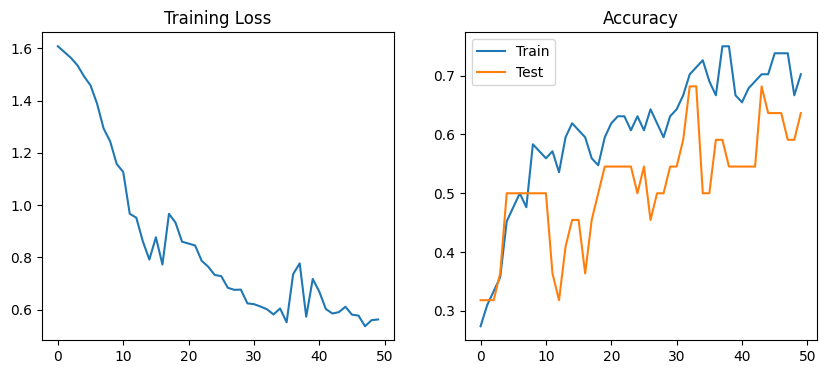

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train")
plt.plot(test_accuracies, label="Test")
plt.title("Accuracy")
plt.legend()

plt.show()

In [21]:

# Save model AFTER training
torch.save(model.state_dict(), "data_glove_lstm.pth")

In [22]:
# Evaluation
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_targets.extend(batch_y.numpy())

acc = accuracy_score(all_targets, all_preds)
print(f"\nTest Accuracy: {acc:.4f}")

# Generate target names from label_to_idx
idx_to_label = {v: k for k, v in label_to_idx.items()}
target_names = [idx_to_label[i] for i in range(len(idx_to_label))]

print("\nClassification Report:\n", classification_report(all_targets, all_preds, target_names=target_names))





Test Accuracy: 0.6364

Classification Report:
               precision    recall  f1-score   support

           A       0.50      0.75      0.60         4
           B       1.00      1.00      1.00         4
           C       0.00      0.00      0.00         4
           D       1.00      0.80      0.89         5
           E       0.60      0.60      0.60         5

    accuracy                           0.64        22
   macro avg       0.62      0.63      0.62        22
weighted avg       0.64      0.64      0.63        22



In [23]:
# Predict and print results for the test set
print("\nPredictions on Test Set:")
for i in range(len(all_preds)):
    true_label = idx_to_label[all_targets[i]]
    predicted_label = idx_to_label[all_preds[i]]
    print(f"{i+1}: True = {true_label}, Predicted = {predicted_label}")


Predictions on Test Set:
1: True = D, Predicted = D
2: True = E, Predicted = E
3: True = C, Predicted = A
4: True = E, Predicted = C
5: True = D, Predicted = D
6: True = B, Predicted = B
7: True = A, Predicted = A
8: True = C, Predicted = A
9: True = E, Predicted = C
10: True = E, Predicted = E
11: True = C, Predicted = A
12: True = D, Predicted = D
13: True = B, Predicted = B
14: True = D, Predicted = E
15: True = B, Predicted = B
16: True = A, Predicted = A
17: True = A, Predicted = A
18: True = A, Predicted = C
19: True = B, Predicted = B
20: True = C, Predicted = E
21: True = E, Predicted = E
22: True = D, Predicted = D


In [22]:
print("\nIncorrect Predictions:")
for i in range(len(all_preds)):
    if all_preds[i] != all_targets[i]:
        true_label = idx_to_label[all_targets[i]]
        predicted_label = idx_to_label[all_preds[i]]
        print(f"Sample {i+1}: True = {true_label}, Predicted = {predicted_label}")


Incorrect Predictions:
Sample 4: True = E, Predicted = C
Sample 14: True = D, Predicted = B
Sample 20: True = C, Predicted = E


In [3]:
torch.save(model.state_dict(), "data_glove_lstm_86_per.pth")

NameError: name 'model' is not defined